In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.stats.proportion import proportion_confint

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn import metrics

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', lambda x: f'{x:.4f}')
RNG = 6587

## 1. Load and inspect the data

In [2]:
df = pd.read_csv('apda_companies_pooled.csv')
print('Shape:', df.shape)
df.head()

Shape: (77, 11)


,company,group_member,sector,sub_sector,disclosure,confirmed_pricing,loyalty,public,size_bucket,revenue_b,notes
0,Bloomingdale's,arjun,retail,general_merchandise,0,0,1,1,Large,2.8000,NaN
1,eBay,arjun,retail,general_merchandise,0,0,0,1,Very Large,10.3000,personalized coupons not pricing
2,Etsy,arjun,retail,general_merchandise,0,0,0,1,Large,2.8000,personalized coupons not pricing
3,Macy's,arjun,retail,general_merchandise,0,0,1,1,Very Large,23.0000,NaN
4,Saks Fifth Avenue,arjun,retail,general_merchandise,0,1,1,0,Very Large,6.0000,privacy policy admits price/service difference...


In [3]:
print('Disclosure rate (full sample):', df['disclosure'].mean().round(3))
print('Regulated firms (confirmed_pricing == 1):', int(df['confirmed_pricing'].sum()))
print('Disclosure positives (full sample):', int(df['disclosure'].sum()))
print('\nDisclosure x confirmed_pricing crosstab:')
print(pd.crosstab(df['confirmed_pricing'], df['disclosure'],
                  rownames=['confirmed_pricing'], colnames=['disclosure']))

Disclosure rate (full sample): 0.156
Regulated firms (confirmed_pricing == 1): 30
Disclosure positives (full sample): 12

Disclosure x confirmed_pricing crosstab:
disclosure          0   1
confirmed_pricing        
0                  47   0
1                  18  12


## 2. Exploratory data analysis

Proportion plots show how the disclosure rate varies across each candidate predictor. Useful for the writeup; also a sanity check on the regression results below.

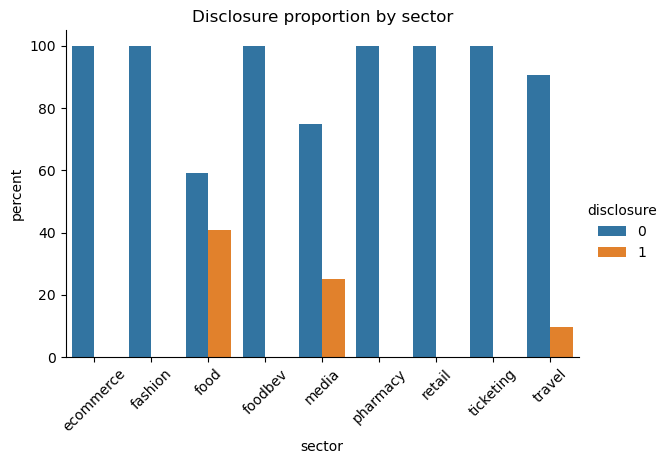

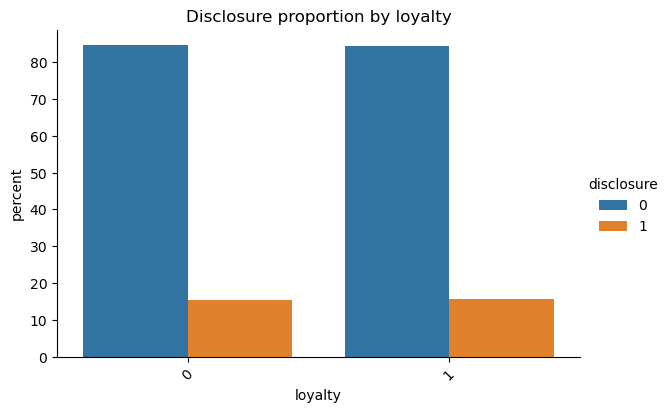

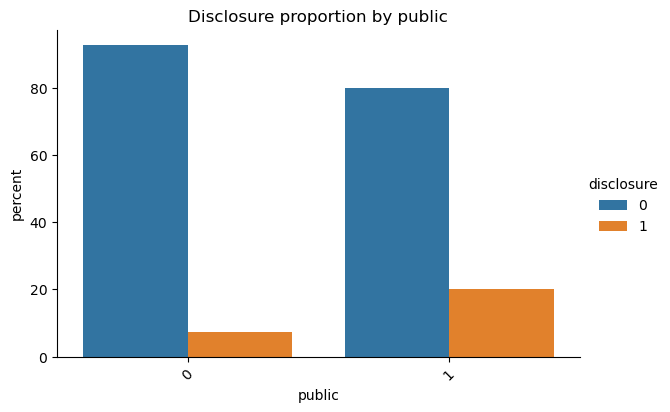

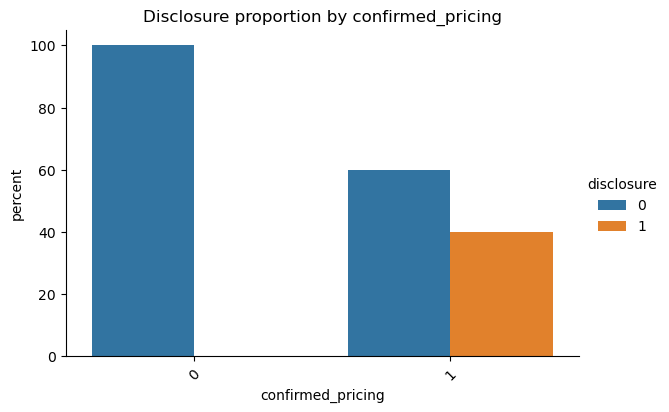

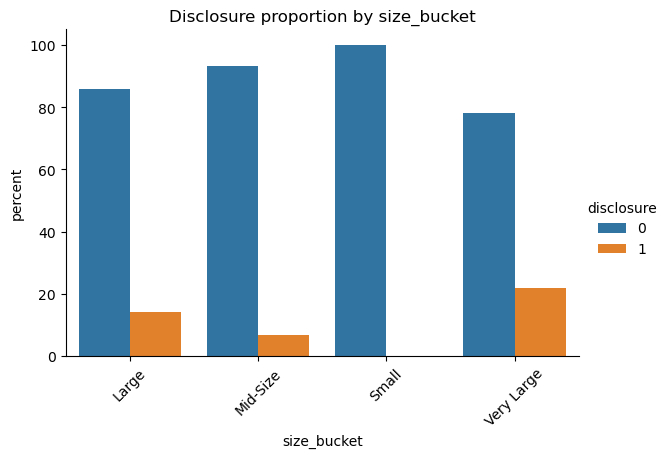

In [4]:
# Proportion plots: disclosure rate by category for each candidate predictor
categorical = ['sector', 'loyalty', 'public', 'confirmed_pricing', 'size_bucket']

for col in categorical:
    prop = df.groupby(col)['disclosure'].value_counts(normalize=True)
    perct_df = (prop * 100).reset_index(name='percent')
    g = sns.catplot(x=col, y='percent', hue='disclosure', data=perct_df,
                    kind='bar', height=4, aspect=1.5)
    g.set(title=f'Disclosure proportion by {col}')
    plt.xticks(rotation=45)
    plt.show()

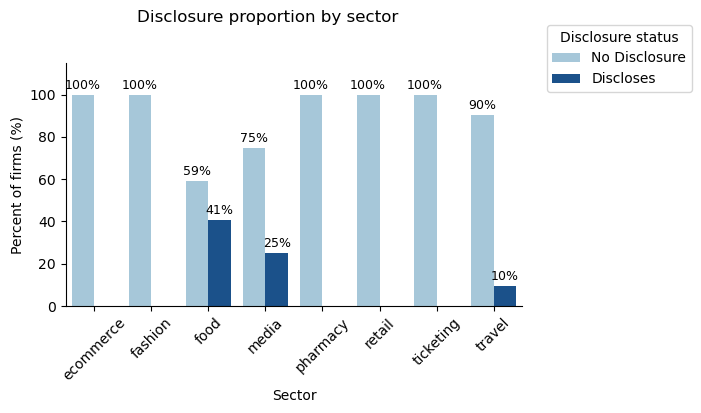

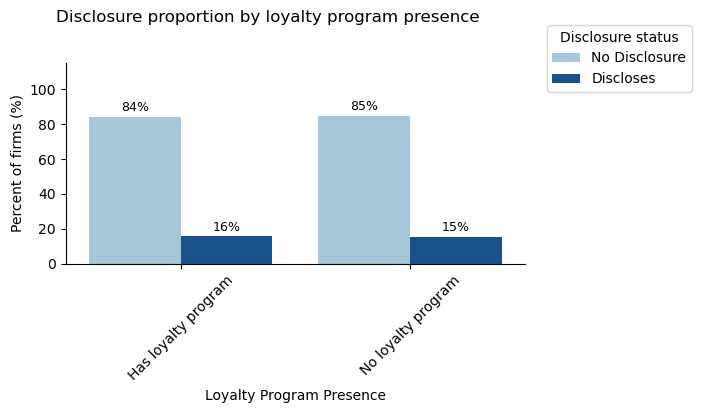

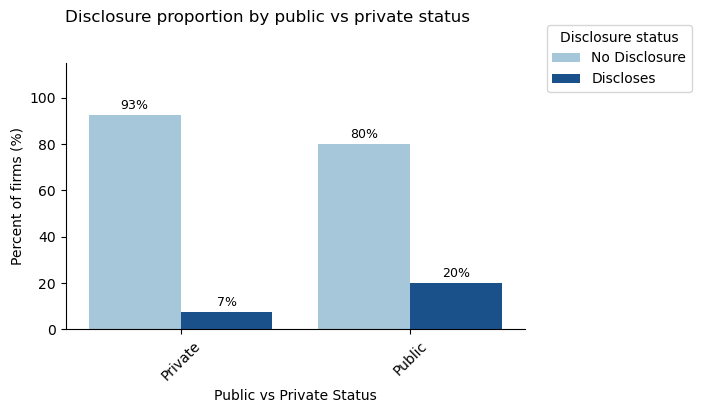

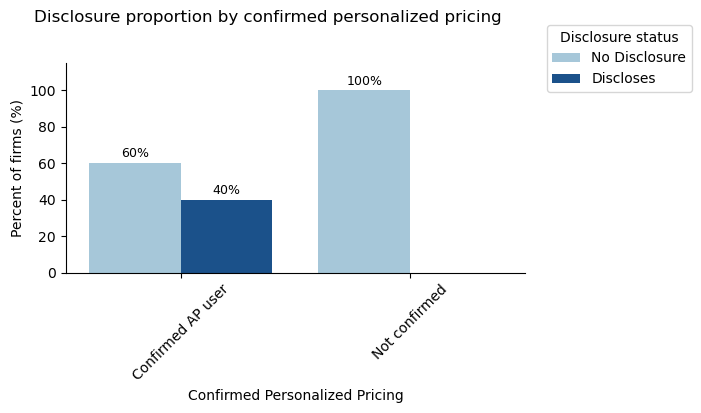

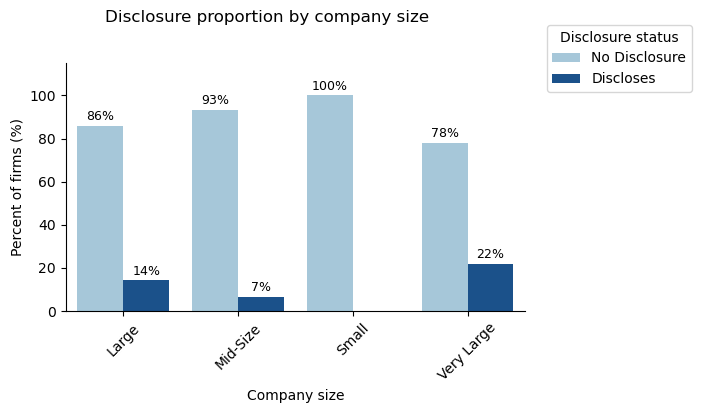

In [10]:
# Friendly labels for binary/categorical variables
label_maps = {
    'loyalty': {0: 'No loyalty program', 1: 'Has loyalty program'},
    'public': {0: 'Private', 1: 'Public'},
    'confirmed_pricing': {0: 'Not confirmed', 1: 'Confirmed AP user'},
}

# Friendly axis titles for each variable
axis_titles = {
    'sector': 'Sector',
    'loyalty': 'Loyalty Program Presence',
    'public': 'Public vs Private Status',
    'confirmed_pricing': 'Confirmed Personalized Pricing',
    'size_bucket': 'Company size',
}

# Friendly title for the disclosure outcome legend
disclosure_label = {0: 'No Disclosure', 1: 'Discloses'}

categorical = ['sector', 'loyalty', 'public', 'confirmed_pricing', 'size_bucket']

for col in categorical:
    plot_df = df[[col, 'disclosure']].copy()

    if col == 'sector':
        plot_df = plot_df[plot_df[col] != 'foodbev']

    if col in label_maps:
        plot_df[col] = plot_df[col].map(label_maps[col])
    plot_df['disclosure'] = plot_df['disclosure'].map(disclosure_label)

    plot_df = plot_df.rename(columns={'disclosure': 'Disclosure status'})

    prop = plot_df.groupby(col)['Disclosure status'].value_counts(normalize=True)
    perct_df = (prop * 100).reset_index(name='percent')

    g = sns.catplot(
        x=col, y='percent', hue='Disclosure status', data=perct_df,
        kind='bar', height=4, aspect=1,
        palette={'No Disclosure': '#9ecae1', 'Discloses': '#08519c'}
    )
    g.set_axis_labels(axis_titles[col], 'Percent of firms (%)')
    g.fig.suptitle(f'Disclosure proportion by {axis_titles[col].lower()}', y=1.02)

    # Move legend outside the plot area
    sns.move_legend(g, "upper left", bbox_to_anchor=(1.0, 1.0), frameon=True)

    # Add percentage labels on top of non-zero bars
    ax = g.ax
    for container in ax.containers:
        labels = [f'{v.get_height():.0f}%' if v.get_height() > 0 else '' for v in container]
        ax.bar_label(container, labels=labels, padding=2, fontsize=9)

    # Give the y-axis headroom for the labels
    ax.set_ylim(0, 115)

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [7]:
print(df['size_bucket'].unique())
print('dtype:', df['size_bucket'].dtype)

['Large' 'Very Large' 'Mid-Size' 'Small']
dtype: object


In [ ]:
df['revenue_b'] = df['revenue_b'].fillna(df['revenue_b'].median())
df['log_revenue'] = np.log(df['revenue_b'])

small_sectors = ['fashion', 'pharmacy', 'foodbev', 'ecommerce']
df.loc[df['sector'].isin(small_sectors), 'sector'] = 'other'
print('Sector counts (full sample):')
print(df['sector'].value_counts())

In [ ]:
# Full-sample disclosure rate
n_all = len(df)
k_all = int(df['disclosure'].sum())
rate_all = k_all / n_all
lo_all, hi_all = proportion_confint(k_all, n_all, alpha=0.05, method='wilson')
print(f'Full sample disclosure rate:  {k_all}/{n_all} = {rate_all:.1%}')
print(f'Wilson 95% CI:                [{lo_all:.1%}, {hi_all:.1%}]')

# Among firms flagged as confirmed users of personalized pricing (caveat: manually coded)
reg = df[df['confirmed_pricing'] == 1].copy()
n_reg = len(reg)
k_disc = int(reg['disclosure'].sum())
rate_reg = k_disc / n_reg
ci_lo, ci_hi = proportion_confint(k_disc, n_reg, alpha=0.05, method='wilson')
print(f'\nFor comparison — among confirmed_pricing == 1 firms (n={n_reg}):')
print(f'  Rate: {rate_reg:.1%}, Wilson 95% CI: [{ci_lo:.1%}, {ci_hi:.1%}]')
print('  (caveat: confirmed_pricing is a manual judgment with measurement error)')

In [ ]:
# Build the modeling frame on the full sample
df['is_food'] = (df['sector'] == 'food').astype(int)

print('Disclosure by is_food (full sample):')
print(pd.crosstab(df['is_food'], df['disclosure'],
                  rownames=['is_food'], colnames=['disclosure']))

X = sm.add_constant(
    df[['log_revenue', 'public', 'loyalty', 'is_food']].astype(float),
    has_constant='add'
)
y = df['disclosure'].astype(int).values
print(f'\nn = {len(y)}, events = {int(y.sum())}')

In [ ]:
# Fit standard logistic regression
print('=== Full-sample logistic regression ===')
fit = sm.Logit(y, X).fit(disp=False, maxiter=200)
print(fit.summary())

In [ ]:
# Odds ratios with 95% CIs — easier to interpret than log-odds
def or_table(fit):
    params = fit.params
    conf = fit.conf_int()
    return pd.DataFrame({
        'coef': params,
        'std_err': fit.bse,
        'p_value': fit.pvalues,
        'odds_ratio': np.exp(params),
        'or_ci_lo': np.exp(conf[0]),
        'or_ci_hi': np.exp(conf[1]),
    })

print('Odds ratios (95% Wald CI):')
print(or_table(fit).round(4).to_string())

In [ ]:
# Forest plot of odds ratios
ortab = or_table(fit).drop(index='const').sort_values('odds_ratio')

fig, ax = plt.subplots(figsize=(9, 0.5 * len(ortab) + 1.5))
y_pos = np.arange(len(ortab))
xerr_lo = ortab['odds_ratio'].values - np.clip(ortab['or_ci_lo'].values, 1e-3, None)
xerr_hi = np.clip(ortab['or_ci_hi'].values, None, 1e3) - ortab['odds_ratio'].values
ax.errorbar(ortab['odds_ratio'], y_pos, xerr=[xerr_lo, xerr_hi],
            fmt='o', color='steelblue', ecolor='gray', capsize=3)
ax.set_yticks(y_pos)
ax.set_yticklabels(['Loyalty Program Presence','Annual Revenue' , 'Public/Private Status', 'Sector (Food/Grocery)'])
ax.axvline(1.0, color='black', linestyle='--', linewidth=0.8)
ax.set_xscale('log')
ax.set_xlabel('Odds ratio (log scale)')
ax.set_title('Predictors of Disclosure')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
X_sens = sm.add_constant(
    df[['log_revenue', 'public', 'loyalty', 'is_food', 'confirmed_pricing']].astype(float),
    has_constant='add'
)
print('=== Sensitivity model — adds confirmed_pricing ===')
try:
    fit_sens = sm.Logit(y, X_sens).fit(disp=False, maxiter=200)
    print(fit_sens.summary())
    print('\nOdds ratios (95% Wald CI):')
    print(or_table(fit_sens).round(4).to_string())
    if (np.abs(fit_sens.params) > 10).any() or (fit_sens.bse > 10).any():
        print('\nNOTE: confirmed_pricing is near-perfectly predictive of disclosure (no non-regulated firm discloses),')
        print('which inflates its coefficient and SE. The other coefficients can still be compared to the primary model.')
except Exception as e:
    print(f'Sensitivity model failed: {type(e).__name__}: {e}')
    print('This is expected if confirmed_pricing perfectly separates the outcome — see the primary model above.')

In [ ]:
# LASSO on the same four predictors as the regression
X_lasso = df[['log_revenue', 'public', 'loyalty', 'is_food']].astype(float).copy()
y_lasso = df['disclosure'].astype(int).values

# Standardize log_revenue so coefficients are on a comparable scale
scaler = StandardScaler().fit(X_lasso[['log_revenue']])
X_lasso['log_revenue'] = scaler.transform(X_lasso[['log_revenue']])

# CV over lambda to find the best regularization strength
lambdas = np.logspace(-2, 1.4, 10)
cv = StratifiedKFold(n_splits=5, random_state=RNG, shuffle=True)
lasso_search = GridSearchCV(
    estimator=LogisticRegression(class_weight='balanced', solver='saga',
                                 penalty='l1', max_iter=5000, random_state=RNG),
    param_grid={'C': 1 / lambdas}, scoring='roc_auc', cv=cv, n_jobs=-1
)
lasso_search.fit(X_lasso, y_lasso)

print(f'Best C (=1/lambda): {lasso_search.best_params_["C"]:.3f}')
print(f'Best CV AUC:        {lasso_search.best_score_:.3f}')
print()

best_lasso = lasso_search.best_estimator_
lasso_coefs = pd.DataFrame({
    'predictor': X_lasso.columns,
    'lasso_coef_standardized': best_lasso.coef_[0],
}).sort_values('lasso_coef_standardized', key=abs, ascending=False)
print('LASSO coefficients (standardized scale):')
print(lasso_coefs.to_string(index=False))

In [ ]:
# In-sample ROC for the §5 regression
y_pred_in = fit.predict(X)
fpr_in, tpr_in, _ = metrics.roc_curve(y, y_pred_in)
auc_in = metrics.roc_auc_score(y, y_pred_in)

# 5-fold cross-validated ROC
cv_roc = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)
y_proba_cv = np.zeros(len(y), dtype=float)
for tr, te in cv_roc.split(X, y):
    fit_cv = sm.Logit(y[tr], X.iloc[tr]).fit(disp=False, maxiter=200)
    y_proba_cv[te] = fit_cv.predict(X.iloc[te])
fpr_cv, tpr_cv, _ = metrics.roc_curve(y, y_proba_cv)
auc_cv = metrics.roc_auc_score(y, y_proba_cv)

print(f'In-sample AUC:  {auc_in:.3f}')
print(f'5-fold CV AUC:  {auc_cv:.3f}')
print(f'Optimism gap:   {auc_in - auc_cv:.3f}')

plt.figure(figsize=(7, 7))
plt.plot(fpr_in, tpr_in, lw=2, label=f'In-sample (AUC = {auc_in:.3f})')
plt.plot(fpr_cv, tpr_cv, lw=2, label=f'5-fold CV (AUC = {auc_cv:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix

# Use cross-validated predictions from §7 for an honest view
threshold = 0.5
y_pred_cv = (y_proba_cv >= threshold).astype(int)
cm = confusion_matrix(y, y_pred_cv)
tn, fp, fn, tp = cm.ravel()

# Heatmap
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', cbar=True,
    xticklabels=['Predicted: no disclosure', 'Predicted: disclosure'],
    yticklabels=['Actual: no disclosure', 'Actual: disclosure'],
    ax=ax
)
ax.set_title(f'Confusion matrix, Threshold = {threshold})')
plt.tight_layout()
plt.show()

# Plain-English interpretation
total = len(y)
print(f'At threshold = {threshold} (cross-validated):')
print(f'  True positives  (correctly flagged disclosers):    {tp} of {tp+fn}')
print(f'  False negatives (missed actual disclosers):        {fn}')
print(f'  True negatives  (correctly identified non-disclosers): {tn} of {tn+fp}')
print(f'  False positives (wrongly flagged as disclosers):   {fp}')
print()
print(f'  Sensitivity (recall, TPR): {tp / (tp + fn):.1%}  — share of actual disclosers the model catches')
print(f'  Specificity (TNR):         {tn / (tn + fp):.1%}  — share of non-disclosers correctly cleared')
if tp + fp > 0:
    print(f'  Precision (PPV):           {tp / (tp + fp):.1%}  — share of model-flagged firms that actually disclose')
print(f'  Overall accuracy:          {(tp + tn) / total:.1%}')